# Nickname Dataset Analysis — Vulgar Nickname Moderation Model

**Goal:** Quantitative analysis of datasets containing **actual usernames/nicknames** for training a PL nickname moderation model.

**Nickname-specific datasets:**
- **Namespotting** — ~329k Reddit usernames with toxicity labels (EN)
- **Steam PL profanity filter** — Valve's production filter for Polish
- **coldner/wulgaryzmy** — Polish profanity word list
- **BAN-PL vulgarisms** — extended Polish vulgarism list
- **LDNOOBW PL** — Polish bad words
- **BAN-PL_1 / BAN-PL_2** — Wykop.pl posts (source for PL profanity extraction)
- **Surge AI** — EN profanity with severity ratings

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json, os, io, msoffcrypto
from collections import Counter
from datasets import load_from_disk

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100
DATA = "data"

## 1. Namespotting — Reddit Usernames with Toxicity Labels

The **only publicly available dataset of real usernames with toxicity labels.**
- `usernamesToxicOrNot.tsv` — full dataset (toxic / non-toxic)
- `suspensionsA/B` — granular nick labels: nickOffensive, nickProfanity, nickSexual, nickInappropriate

=== usernamesToxicOrNot.tsv ===
Size: 4,499,813 usernames

Toxicity label distribution:
toxic_label
non-toxic    4377655
toxic         122158

Username length stats:
count    4.499813e+06
mean     1.107942e+01
std      3.554611e+00
min      3.000000e+00
25%      8.000000e+00
50%      1.100000e+01
75%      1.300000e+01
max      2.000000e+01

Usernames ≤20 chars: 4,499,813 (100.0%)
Usernames ≤32 chars: 4,499,813 (100.0%)

Toxic nick examples: ['NakedGoose', 'DumbComment101', 'buttscopedoctor', 'TheNotoriousFAP', 'killjews88', 'Donghoon', 'hornybanana69', 'Happyskrappy', 'UPGRADED_BUTTHOLE', 'Catshit-Dogfart', 'imstilldoingthisshit', 'chuckdacuck', 'PartiZAn18', 'UniversalJampionshit', 'TheBaltimoron']
Clean nick examples: ['karmakedi', 'monkeiboi', 'JackFrost___', 'ahhall22', 'Gary_l_collins', 'themariokarters', 'maurid', 'oppaixd69', 'Parker_GTAV', 'urfriendosvendo', '3GRAMS_GKRACK', 'Suzy2QQ', 'DaveTravis', 'altleftout', 'bogeyworkman']


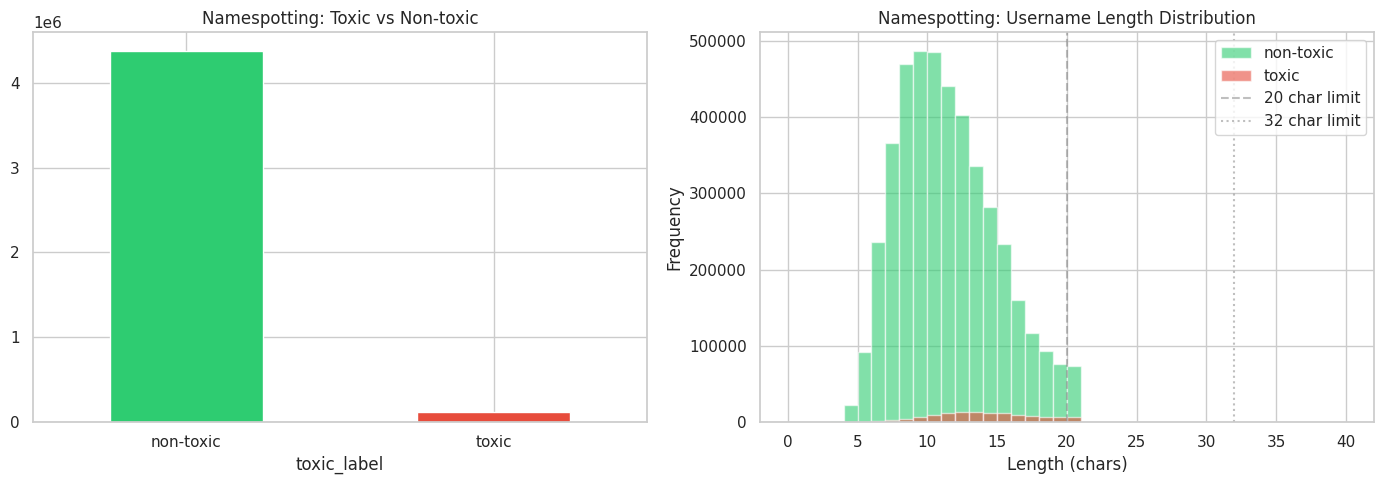

In [27]:
# Main dataset: usernamesToxicOrNot.tsv
ns_main = pd.read_csv(f"{DATA}/namespotting_data/datasets/usernamesToxicOrNot.tsv", sep='\t',
                       header=None, names=['username', 'toxic_label', 'col3', 'type'])
print(f"=== usernamesToxicOrNot.tsv ===")
print(f"Size: {len(ns_main):,} usernames")
print(f"\nToxicity label distribution:")
print(ns_main['toxic_label'].value_counts().to_string())
print(f"\nUsername length stats:")
ns_main['nick_len'] = ns_main['username'].str.len()
print(ns_main['nick_len'].describe().to_string())
print(f"\nUsernames ≤20 chars: {(ns_main['nick_len'] <= 20).sum():,} ({(ns_main['nick_len'] <= 20).mean()*100:.1f}%)")
print(f"Usernames ≤32 chars: {(ns_main['nick_len'] <= 32).sum():,} ({(ns_main['nick_len'] <= 32).mean()*100:.1f}%)")

# Examples
toxic = ns_main[ns_main['toxic_label'] == 'toxic']
nontoxic = ns_main[ns_main['toxic_label'] == 'non-toxic']
print(f"\nToxic nick examples: {toxic['username'].head(15).tolist()}")
print(f"Clean nick examples: {nontoxic['username'].head(15).tolist()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ns_main['toxic_label'].value_counts().plot.bar(ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Namespotting: Toxic vs Non-toxic')
axes[0].tick_params(axis='x', rotation=0)

for label, color in [('non-toxic', '#2ecc71'), ('toxic', '#e74c3c')]:
    ns_main[ns_main['toxic_label'] == label]['nick_len'].plot.hist(
        ax=axes[1], bins=40, alpha=0.6, color=color, label=label, range=(0, 40))
axes[1].set_title('Namespotting: Username Length Distribution')
axes[1].set_xlabel('Length (chars)')
axes[1].axvline(x=20, color='gray', linestyle='--', alpha=0.5, label='20 char limit')
axes[1].axvline(x=32, color='gray', linestyle=':', alpha=0.5, label='32 char limit')
axes[1].legend()
plt.tight_layout()
plt.show()

### 1b. Namespotting — Granular Nick Toxicity Labels (suspensions A+B)

/tmp/ipykernel_1948377/2642508868.py:2: DtypeWarning: Columns (0: V3) have mixed types. Specify dtype option on import or set low_memory=False.
  sa = pd.read_csv(f"{DATA}/namespotting_data/datasets/suspensionsAdone.csv")


=== Suspensions A+B (granular nick labels) ===
Total unique users: 192,627
Toxic nicks: toxic
non-toxic    99814
toxic        92813

Users with ANY nick toxicity flag: 92,813

Nick toxicity breakdown:
  nickInappropriate: 21,189
  nickOffensive: 22,602
  nickProfanity: 10,256
  nickSexual: 43,483

Nick length stats:
count    192627.000000
mean         12.280485
std           3.734253
min           3.000000
25%           9.000000
50%          12.000000
75%          15.000000
max          20.000000

  nickInappropriate examples: ['anothershitposter2', 'suckasurprise', 'MrB00tyButtstache', 'Killmeplease1904', 'suckingonabanana', 'Thotianna0utSouth', 'AlfredShitCasket', 'IncrediblyDopeShit', 'Dumbificate', 'billsmafiabruh']

  nickOffensive examples: ['bimboslutlover2', '_Patronizes_Idiots_', 'youlovetherepgame', 'Bearthatatethosekids', 'whiteboy059', 'bitchasswhore777', 'Goonerboy88', 'bimbo-is-best', 'Blondeambitchion', 'BangoSkank1919']

  nickProfanity examples: ['fucktreesnothugthem',

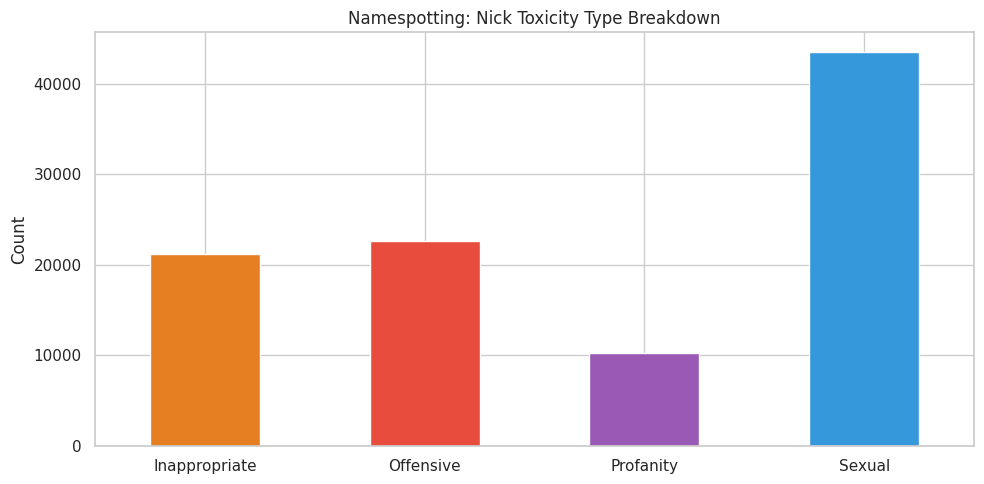

In [28]:
# Granular nick labels from suspensions datasets
sa = pd.read_csv(f"{DATA}/namespotting_data/datasets/suspensionsAdone.csv")
sb = pd.read_csv(f"{DATA}/namespotting_data/datasets/suspensionsBdone.csv")
susp = pd.concat([sa, sb], ignore_index=True).drop_duplicates(subset='user')

nick_cols = ['nickInappropriate', 'nickOffensive', 'nickProfanity', 'nickSexual']
print(f"=== Suspensions A+B (granular nick labels) ===")
print(f"Total unique users: {len(susp):,}")
print(f"Toxic nicks: {susp['toxic'].value_counts().to_string()}")

# Users with any nick-level toxicity flag
susp['any_nick_toxic'] = susp[nick_cols].sum(axis=1) > 0
print(f"\nUsers with ANY nick toxicity flag: {susp['any_nick_toxic'].sum():,}")
print(f"\nNick toxicity breakdown:")
for c in nick_cols:
    print(f"  {c}: {susp[c].sum():,}")

print(f"\nNick length stats:")
susp['nick_len'] = susp['user'].str.len()
print(susp['nick_len'].describe().to_string())

# Examples of each category
for c in nick_cols:
    examples = susp[susp[c] == 1]['user'].head(10).tolist()
    print(f"\n  {c} examples: {examples}")

fig, ax = plt.subplots(figsize=(10, 5))
nick_counts = {c.replace('nick', ''): susp[c].sum() for c in nick_cols}
pd.Series(nick_counts).plot.bar(ax=ax, color=['#e67e22', '#e74c3c', '#9b59b6', '#3498db'])
ax.set_title('Namespotting: Nick Toxicity Type Breakdown')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## 2. Polish Word Lists — Steam Filter + coldner + BAN-PL + LDNOOBW

In [29]:
print("=" * 60)
print("POLISH WORD LISTS FOR NICKNAME FILTERING")
print("=" * 60)

# Steam PL profanity filter (Valve production)
steam_banned = [w.strip() for w in open(f"{DATA}/steam-profanity-filter/polish/polish-banned.txt", encoding='utf-8') if w.strip()]
steam_prof = [w.strip() for w in open(f"{DATA}/steam-profanity-filter/polish/polish-profanity.txt", encoding='utf-8') if w.strip()]
steam_clean = [w.strip() for w in open(f"{DATA}/steam-profanity-filter/polish/polish-clean_public.txt", encoding='utf-8') if w.strip()]

print(f"\n### Steam PL Profanity Filter (Valve production)")
print(f"  polish-profanity.txt: {len(steam_prof):,} words (main profanity list)")
print(f"  polish-banned.txt:    {len(steam_banned):,} words (banned terms)")
print(f"  polish-clean.txt:     {len(steam_clean):,} words (false positive whitelist)")
print(f"  Avg word length (profanity): {sum(len(w) for w in steam_prof)/len(steam_prof):.1f}")
print(f"  Max word length: {max(len(w) for w in steam_prof)}")
steam_all_pl = list(set(steam_prof + steam_banned))
print(f"  Combined unique PL words: {len(steam_all_pl):,}")

# coldner/wulgaryzmy
with open(f"{DATA}/wulgaryzmy/wulgaryzmy.json", encoding='utf-8') as f:
    coldner = json.load(f)
print(f"\n### coldner/wulgaryzmy")
print(f"  Entries: {len(coldner):,}")
print(f"  Avg length: {sum(len(w) for w in coldner)/len(coldner):.1f}")
print(f"  Samples: {coldner[:15]}")

# BAN-PL vulgarisms
vulg = [l.strip() for l in open(f"{DATA}/BAN-PL/resources/polish_vulgarisms_extended_2.0.txt.", encoding='utf-8') if l.strip()]
print(f"\n### BAN-PL polish_vulgarisms_extended")
print(f"  Entries: {len(vulg):,}")
print(f"  Avg length: {sum(len(w) for w in vulg)/len(vulg):.1f}")

# LDNOOBW PL
ldpl = [w.strip() for w in open(f"{DATA}/LDNOOBW/pl", encoding='utf-8') if w.strip()]
print(f"\n### LDNOOBW PL")
print(f"  Words: {len(ldpl)}")

# Merge all PL lists and check overlap
all_pl_words = set(w.lower() for w in steam_all_pl + coldner + vulg + ldpl)
print(f"\n{'='*60}")
print(f"COMBINED PL WORD LIST:")
print(f"  Steam PL (unique):    {len(set(w.lower() for w in steam_all_pl)):,}")
print(f"  coldner:              {len(set(w.lower() for w in coldner)):,}")
print(f"  BAN-PL vulg:          {len(set(w.lower() for w in vulg)):,}")
print(f"  LDNOOBW PL:           {len(set(w.lower() for w in ldpl)):,}")
print(f"  ─────────────────────────────────")
print(f"  TOTAL UNIQUE PL:      {len(all_pl_words):,}")

# Overlap matrix
sets = {
    'Steam': set(w.lower() for w in steam_all_pl),
    'coldner': set(w.lower() for w in coldner),
    'BAN-PL': set(w.lower() for w in vulg),
    'LDNOOBW': set(w.lower() for w in ldpl),
}
print(f"\nOverlap matrix (intersection sizes):")
for n1, s1 in sets.items():
    overlaps = {n2: len(s1 & s2) for n2, s2 in sets.items()}
    print(f"  {n1:10s}: {overlaps}")

# Length distribution
all_pl_list = list(all_pl_words)
lens = [len(w) for w in all_pl_list]
print(f"\nPL word length distribution:")
print(f"  ≤5 chars:  {sum(1 for l in lens if l <= 5):,}")
print(f"  6-10:      {sum(1 for l in lens if 6 <= l <= 10):,}")
print(f"  11-15:     {sum(1 for l in lens if 11 <= l <= 15):,}")
print(f"  16-20:     {sum(1 for l in lens if 16 <= l <= 20):,}")
print(f"  >20:       {sum(1 for l in lens if l > 20):,}")

POLISH WORD LISTS FOR NICKNAME FILTERING

### Steam PL Profanity Filter (Valve production)
  polish-profanity.txt: 6,842 words (main profanity list)
  polish-banned.txt:    259 words (banned terms)
  polish-clean.txt:     23 words (false positive whitelist)
  Avg word length (profanity): 10.1
  Max word length: 20
  Combined unique PL words: 7,101

### coldner/wulgaryzmy
  Entries: 711
  Avg length: 8.9
  Samples: ['chuj', 'chuja', 'chujek', 'chujem', 'chujnia', 'chujowa', 'chujowe', 'chujowy', 'chuju', 'ciot', 'ciota', 'cip', 'cipa', 'cipach', 'cipami']

### BAN-PL polish_vulgarisms_extended
  Entries: 6,482
  Avg length: 12.4

### LDNOOBW PL
  Words: 54

COMBINED PL WORD LIST:
  Steam PL (unique):    7,101
  coldner:              711
  BAN-PL vulg:          6,482
  LDNOOBW PL:           54
  ─────────────────────────────────
  TOTAL UNIQUE PL:      11,403

Overlap matrix (intersection sizes):
  Steam     : {'Steam': 7101, 'coldner': 572, 'BAN-PL': 2254, 'LDNOOBW': 29}
  coldner   : {

## 3. BAN-PL — Wykop Posts (for PL profanity extraction + short text analysis)

In [30]:
ban1 = pd.read_csv(f"{DATA}/BAN-PL/data/BAN-PL_1/BAN-PL.csv")
ban2 = pd.read_csv(f"{DATA}/BAN-PL/data/BAN-PL_2/BAN-PL.csv")

print(f"=== BAN-PL (Wykop.pl moderated posts) ===")
print(f"BAN-PL_1: {len(ban1):,} rows ({ban1['Class'].value_counts().to_dict()})")
print(f"BAN-PL_2: {len(ban2):,} rows ({ban2['Class'].value_counts().to_dict()})")

# Extract single-word harmful content (closest to nicknames)
ban_all = pd.concat([
    ban1[['Text', 'Class']].rename(columns={'Text': 'text', 'Class': 'label'}),
    ban2[['Text', 'Class']].rename(columns={'Text': 'text', 'Class': 'label'})
])
ban_all['text_len'] = ban_all['text'].str.len()
ban_all['word_count'] = ban_all['text'].str.split().str.len()

# Nick-like: single word, ≤32 chars
nick_like = ban_all[(ban_all['word_count'] == 1) & (ban_all['text_len'] <= 32)]
print(f"\nSingle-word entries ≤32ch (nick-like): {len(nick_like):,}")
print(f"  harmful: {len(nick_like[nick_like['label']==1]):,}")
print(f"  neutral: {len(nick_like[nick_like['label']==0]):,}")
if len(nick_like[nick_like['label']==1]) > 0:
    print(f"  Harmful single-word samples: {nick_like[nick_like['label']==1]['text'].head(20).tolist()}")

# Short entries ≤32ch (potential nick material)
short = ban_all[ban_all['text_len'] <= 32]
print(f"\nAll entries ≤32ch: {len(short):,}")
print(f"  harmful: {len(short[short['label']==1]):,}")
print(f"  neutral: {len(short[short['label']==0]):,}")

=== BAN-PL (Wykop.pl moderated posts) ===
BAN-PL_1: 24,000 rows ({0: 12000, 1: 12000})
BAN-PL_2: 24,000 rows ({0: 12000, 1: 12000})

Single-word entries ≤32ch (nick-like): 84
  harmful: 68
  neutral: 16
  Harmful single-word samples: ['Zastrzelić', '#whitepower', 'Kurwiszcze', '<3', 'KURWA!', 'LGBTRUP', 'UTILIZACJA', 'Qrwy!!', 'TOR-PE-DO-WAĆ-KUR-WA-MAĆ', '{USERNAME}:idiota...', '#chujwamwdupe', 'Umrzyj!!!', 'WypierdalaćTSUE', 'nigger', '#niggaslivebelongtootherniggas', 'pedalstwo', 'LGBTQRWY', 'Wieszałbym.', 'Zbombardować', 'jebaniutki']

All entries ≤32ch: 3,662
  harmful: 2,546
  neutral: 1,116


## 4. EN Word Lists — Surge AI + LDNOOBW EN + google-profanity

In [31]:
surge = load_from_disk(f"{DATA}/surgeai_profanity")['train'].to_pandas()
lden = [w.strip() for w in open(f"{DATA}/LDNOOBW/en", encoding='utf-8') if w.strip()]

# google-profanity
gp_all = []
for f in os.listdir(f"{DATA}/google-profanity-words/data"):
    gp_all.extend([w.strip() for w in open(f"{DATA}/google-profanity-words/data/{f}") if w.strip()])

print(f"=== EN Word Lists ===")
print(f"  Surge AI:        {len(surge):,} (with severity 1-6)")
print(f"  LDNOOBW EN:      {len(lden):,}")
print(f"  google-profanity:{len(gp_all):,}")

all_en = set(w.lower() for w in surge['text'].tolist() + lden + gp_all)
print(f"  Combined unique: {len(all_en):,}")

print(f"\nSurge AI severity breakdown:")
print(surge['severity_description'].value_counts().to_string())

=== EN Word Lists ===
  Surge AI:        1,598 (with severity 1-6)
  LDNOOBW EN:      403
  google-profanity:1,620
  Combined unique: 2,696

Surge AI severity breakdown:
severity_description
Strong    713
Severe    463
Mild      422


## 5. Final Summary — What We Have for Nickname Moderation

In [32]:
summary = pd.DataFrame([
    {"Resource": "Namespotting (main)", "Type": "real usernames", "Lang": "EN",
     "Size": f"{len(ns_main):,}", "Labels": "toxic/non-toxic", "Nick-ready": True},
    {"Resource": "Namespotting (susp.)", "Type": "real usernames", "Lang": "EN",
     "Size": f"{len(susp):,}", "Labels": "4 nick toxicity types", "Nick-ready": True},
    {"Resource": "Steam PL filter", "Type": "word list", "Lang": "PL",
     "Size": f"{len(steam_all_pl):,}", "Labels": "profanity/banned", "Nick-ready": True},
    {"Resource": "coldner/wulgaryzmy", "Type": "word list", "Lang": "PL",
     "Size": f"{len(coldner):,}", "Labels": "all vulgar", "Nick-ready": True},
    {"Resource": "BAN-PL vulgarisms", "Type": "word list", "Lang": "PL",
     "Size": f"{len(vulg):,}", "Labels": "all vulgar", "Nick-ready": True},
    {"Resource": "LDNOOBW PL", "Type": "word list", "Lang": "PL",
     "Size": f"{len(ldpl):,}", "Labels": "all vulgar", "Nick-ready": True},
    {"Resource": "BAN-PL posts", "Type": "text posts", "Lang": "PL",
     "Size": f"{len(ban_all):,}", "Labels": "harmful/neutral", "Nick-ready": False},
    {"Resource": "Surge AI EN", "Type": "word list", "Lang": "EN",
     "Size": f"{len(surge):,}", "Labels": "severity 1-6", "Nick-ready": True},
    {"Resource": "LDNOOBW EN", "Type": "word list", "Lang": "EN",
     "Size": f"{len(lden):,}", "Labels": "all vulgar", "Nick-ready": True},
])

print("FINAL RESOURCE SUMMARY FOR NICKNAME MODERATION")
print("=" * 95)
print(summary.to_string(index=False))

print(f"\n{'='*60}")
print(f"DIRECTLY USABLE FOR NICK MODEL:")
print(f"  Real labeled nicknames (Namespotting): ~{len(ns_main):,} EN")
print(f"  Granular nick labels (Namespotting):   ~{len(susp):,} EN")
print(f"  PL vulgar word seed list:              ~{len(all_pl_words):,} unique words")
print(f"  EN vulgar word seed list:              ~{len(all_en):,} unique words")
print(f"  BAN-PL leet-speak mapping:             ready (POPULAR_CHANGES)")
print(f"\nMISSING:")
print(f"  Real POLISH nicknames with labels:     0")
print(f"  => Must generate via augmentation of PL word lists")
print(f"  => Or scrape from Wykop API / Steam PL")

FINAL RESOURCE SUMMARY FOR NICKNAME MODERATION
            Resource           Type Lang      Size                Labels  Nick-ready
 Namespotting (main) real usernames   EN 4,499,813       toxic/non-toxic        True
Namespotting (susp.) real usernames   EN   192,627 4 nick toxicity types        True
     Steam PL filter      word list   PL     7,101      profanity/banned        True
  coldner/wulgaryzmy      word list   PL       711            all vulgar        True
   BAN-PL vulgarisms      word list   PL     6,482            all vulgar        True
          LDNOOBW PL      word list   PL        54            all vulgar        True
        BAN-PL posts     text posts   PL    48,000       harmful/neutral       False
         Surge AI EN      word list   EN     1,598          severity 1-6        True
          LDNOOBW EN      word list   EN       403            all vulgar        True

DIRECTLY USABLE FOR NICK MODEL:
  Real labeled nicknames (Namespotting): ~4,499,813 EN
  Granular nick